In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report
from sklearn.model_selection import cross_val_score

In [3]:
df = pd.read_csv(r'R:\PROJECTS\Public_Transport_Delay_Prediction\public_transport_delays.csv')
df.sample(10)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
1882,T01882,2023-01-20,19:30:00,Bus,Route_17,Station_45,Station_25,19:32:00,19:58:00,7,...,58,4.6,Concert,0,26,0,1,4,Spring,1
1553,T01553,2023-01-17,09:15:00,Metro,Route_9,Station_16,Station_17,09:16:00,10:04:00,-1,...,10,9.4,NaN,2000,46,1,1,1,Summer,1
1601,T01601,2023-01-17,21:15:00,Tram,Route_3,Station_26,Station_28,21:15:00,21:46:00,9,...,8,13.0,Parade,500,79,0,0,1,Summer,1
1860,T01860,2023-01-20,14:00:00,Train,Route_11,Station_1,Station_37,14:04:00,14:45:00,11,...,36,8.7,Concert,0,72,0,0,4,Spring,0
1230,T01230,2023-01-14,00:30:00,Tram,Route_20,Station_38,Station_14,00:32:00,01:00:00,13,...,4,8.1,Protest,0,68,0,0,5,Spring,0
1424,T01424,2023-01-16,01:00:00,Metro,Route_19,Station_50,Station_46,01:00:00,01:54:00,18,...,26,4.2,Concert,50000,11,0,0,0,Summer,0
1938,T01938,2023-01-21,09:30:00,Train,Route_3,Station_50,Station_46,09:31:00,10:14:00,6,...,23,13.2,NaN,0,86,1,0,5,Autumn,1
998,T00998,2023-01-11,14:30:00,Metro,Route_17,Station_47,Station_6,14:33:00,15:11:00,3,...,45,9.2,Protest,50000,85,0,0,2,Spring,0
487,T00487,2023-01-06,06:45:00,Metro,Route_14,Station_10,Station_9,06:47:00,07:10:00,1,...,30,5.4,NaN,0,28,0,0,4,Spring,1
41,T00041,2023-01-01,15:15:00,Tram,Route_2,Station_29,Station_14,15:16:00,16:08:00,11,...,58,14.8,NaN,0,20,0,0,6,Autumn,1


In [4]:
print(f'\nShape of the Dataset: {df.shape}')
print(f'\nColumn of the Dataset: {df.columns}\n')


Shape of the Dataset: (2000, 24)

Column of the Dataset: Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')



In [5]:
print(f'\nDataset Info: {df.info()}')

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [6]:
print(f'\nSummary Statistics: {df.describe()}')


Summary Statistics:        actual_departure_delay_min  actual_arrival_delay_min  temperature_C  \
count                 2000.000000               2000.000000    2000.000000   
mean                     8.688000                 13.318000      15.121350   
std                      6.268118                  9.289727      11.479424   
min                     -2.000000                 -3.000000      -5.000000   
25%                      3.000000                  5.000000       5.100000   
50%                      9.000000                 13.000000      15.300000   
75%                     14.000000                 21.000000      24.800000   
max                     19.000000                 29.000000      35.000000   

       humidity_percent  wind_speed_kmh  precipitation_mm  \
count       2000.000000     2000.000000       2000.000000   
mean          64.714000       29.300500          9.860700   
std           20.334747       17.264015          5.781373   
min           30.000000        0

In [7]:
#Convert date column
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

#Extract hour from time column
df['hour'] = pd.to_datetime(df['time'],format='%H:%M:%S').dt.hour
df


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,year,month,day,hour
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,81,0,1,6,Winter,0,2023,1,1,5
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,53,0,0,6,Autumn,1,2023,1,1,5
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,67,1,0,6,Autumn,0,2023,1,1,5
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,84,0,0,6,Winter,1,2023,1,1,5
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,46,0,0,6,Spring,1,2023,1,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,T01995,2023-01-21,23:45:00,Bus,Route_11,Station_46,Station_39,23:46:00,00:11:00,15,...,96,0,0,5,Winter,1,2023,1,21,23
1996,T01996,2023-01-22,00:00:00,Train,Route_9,Station_44,Station_42,00:03:00,00:41:00,11,...,12,0,1,6,Winter,1,2023,1,22,0
1997,T01997,2023-01-22,00:15:00,Bus,Route_12,Station_4,Station_45,00:18:00,00:35:00,1,...,24,1,0,6,Summer,1,2023,1,22,0
1998,T01998,2023-01-22,00:30:00,Tram,Route_17,Station_29,Station_48,00:34:00,01:18:00,7,...,23,0,0,6,Summer,1,2023,1,22,0


In [8]:
df['time'] = pd.to_datetime(df['time'])
df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'])
df['scheduled_arrival'] = pd.to_datetime(df['scheduled_arrival'])

C:\Users\rahul\AppData\Local\Temp\ipykernel_9388\3197680313.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])
C:\Users\rahul\AppData\Local\Temp\ipykernel_9388\3197680313.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'])
C:\Users\rahul\AppData\Local\Temp\ipykernel_9388\3197680313.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['scheduled_arrival'] = pd.to_datetime(df['scheduled_arrival'])


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trip_id                     2000 non-null   str           
 1   date                        2000 non-null   datetime64[us]
 2   time                        2000 non-null   datetime64[us]
 3   transport_type              2000 non-null   str           
 4   route_id                    2000 non-null   str           
 5   origin_station              2000 non-null   str           
 6   destination_station         2000 non-null   str           
 7   scheduled_departure         2000 non-null   datetime64[us]
 8   scheduled_arrival           2000 non-null   datetime64[us]
 9   actual_departure_delay_min  2000 non-null   int64         
 10  actual_arrival_delay_min    2000 non-null   int64         
 11  weather_condition           2000 non-null   str           
 12  tem

In [10]:
#Check Null values

df.isna().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
year                             0
month                            0
day                              0
hour                             0
dtype: int64

In [11]:
df['event_type'] = df['event_type'].fillna('No Event')
df['event_type'].value_counts()

event_type
No Event    1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

Text(0, 0.5, 'Average Delay (Minutes)')

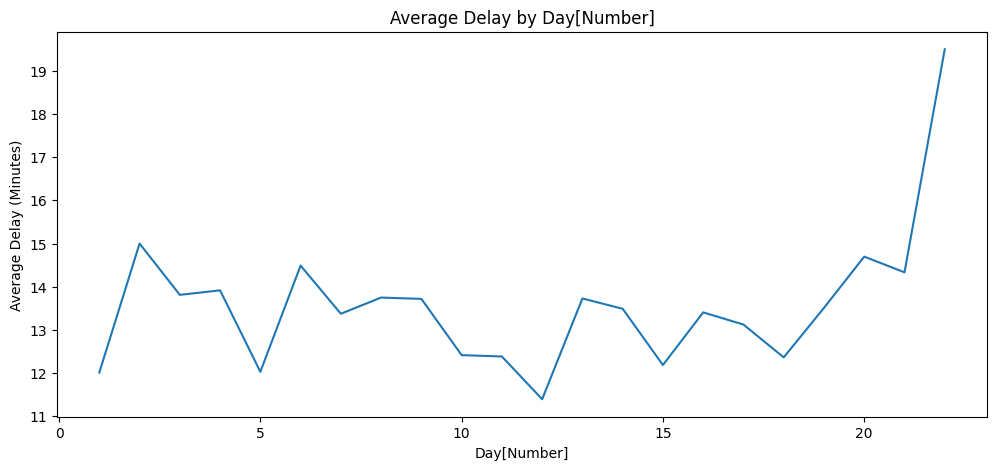

In [12]:
# Delay by Day[Number]

dayNumber_delay = df.groupby(
    "day"
)["actual_arrival_delay_min"].mean()

plt.figure(figsize=(12,5))
dayNumber_delay.plot()
plt.title("Average Delay by Day[Number]")
plt.xlabel("Day[Number]")
plt.ylabel("Average Delay (Minutes)")

Text(0, 0.5, 'Average Delay (Minutes)')

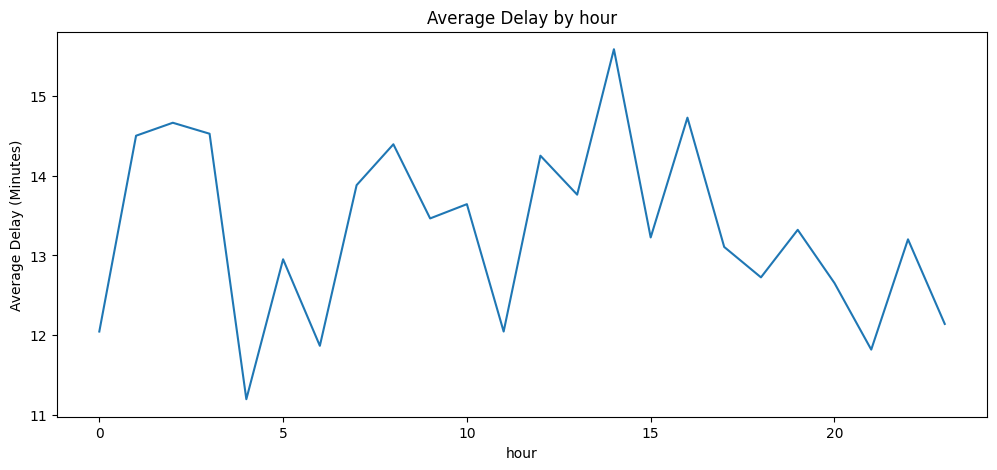

In [13]:
# Delay by hour

hour_delay = df.groupby(
    "hour"
)["actual_arrival_delay_min"].mean()

plt.figure(figsize=(12,5))
hour_delay.plot()
plt.title("Average Delay by hour")
plt.xlabel("hour")
plt.ylabel("Average Delay (Minutes)")

<Axes: xlabel='transport_type'>

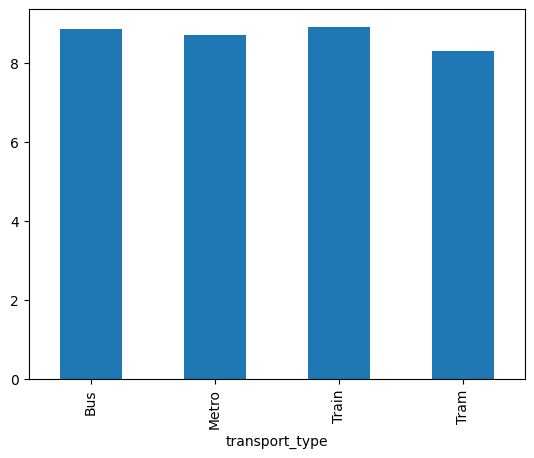

In [14]:
# Delay by transport_type

transport_type_delay = df.groupby('transport_type')['actual_departure_delay_min'].mean()
transport_type_delay.plot(kind='bar')

<Axes: xlabel='weather_condition'>

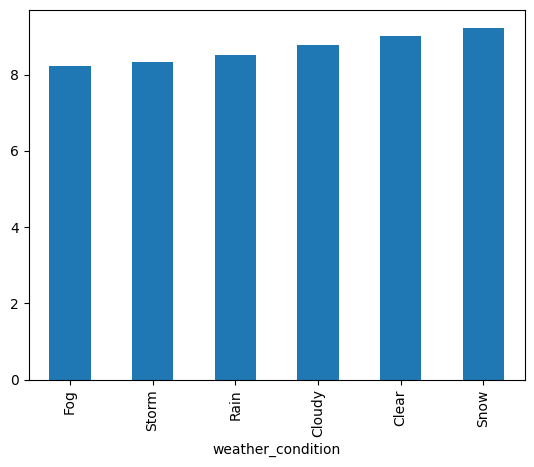

In [15]:
weather_condition_delay = df.groupby('weather_condition')['actual_departure_delay_min'].mean()
weather_condition_delay.sort_values().plot(kind='bar')



Text(0.5, 0, 'RouteIDs')

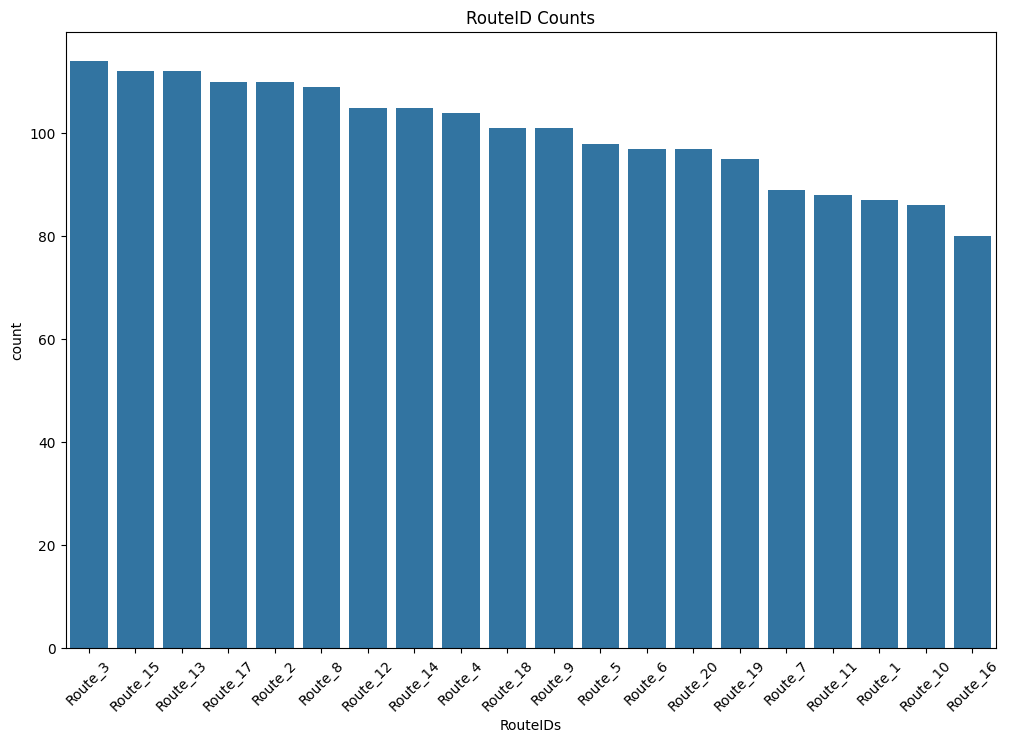

In [16]:
route = df['route_id'].value_counts().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,8))
sns.barplot(data=route,x='route_id',y='count')
plt.xticks(rotation=45)
plt.title("RouteID Counts")
plt.xlabel("RouteIDs")

Text(0.5, 0, 'Arrival Delay (min)')

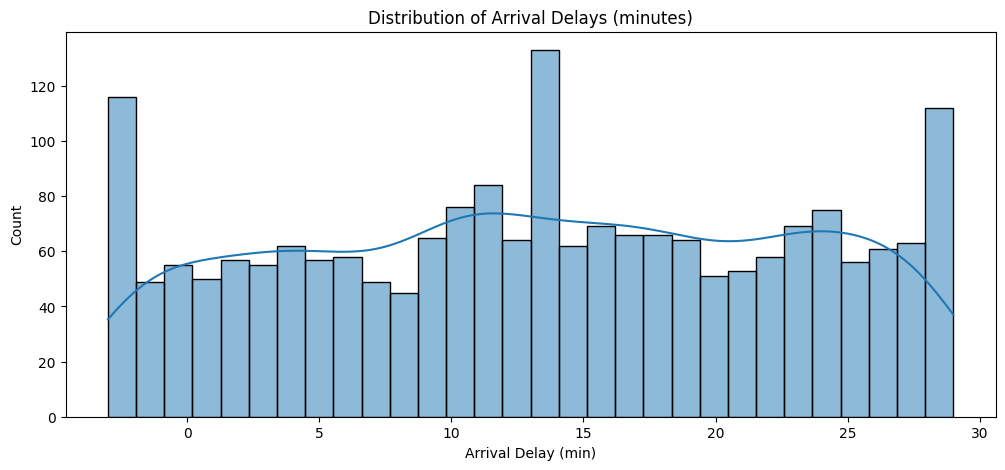

In [17]:
plt.figure(figsize=(12,5))

sns.histplot(data = df, x='actual_arrival_delay_min',bins=30,kde=True)
plt.title("Distribution of Arrival Delays (minutes)")
plt.xlabel("Arrival Delay (min)")

Text(0, 0.5, 'Avg. Delay (min)')

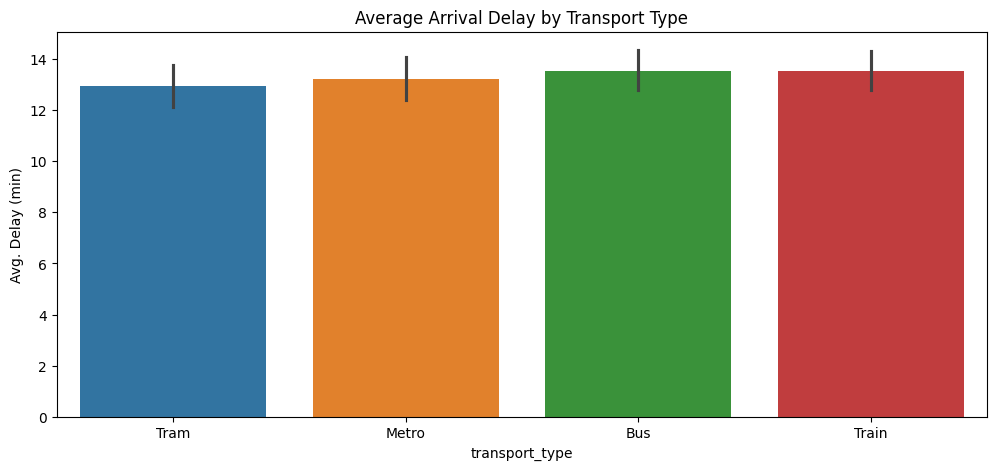

In [18]:
plt.figure(figsize=(12,5))
sns.barplot(data=df, x="transport_type", y="actual_arrival_delay_min", hue="transport_type")
plt.title("Average Arrival Delay by Transport Type")
plt.ylabel("Avg. Delay (min)")

C:\Users\rahul\AppData\Local\Temp\ipykernel_9388\888920684.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="weather_condition", y="actual_arrival_delay_min", palette="coolwarm")


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Storm'),
  Text(1, 0, 'Rain'),
  Text(2, 0, 'Clear'),
  Text(3, 0, 'Snow'),
  Text(4, 0, 'Fog'),
  Text(5, 0, 'Cloudy')])

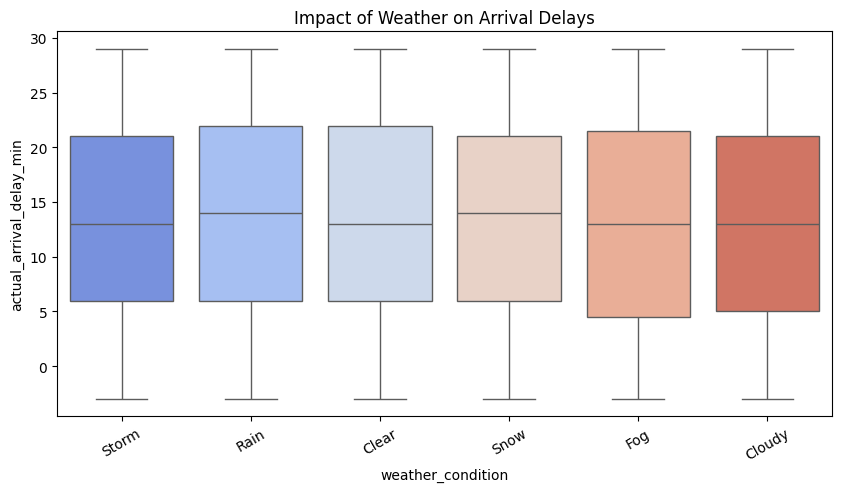

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="weather_condition", y="actual_arrival_delay_min", palette="coolwarm")
plt.title("Impact of Weather on Arrival Delays")
plt.xticks(rotation=30)

C:\Users\rahul\AppData\Local\Temp\ipykernel_9388\1773620233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="event_type", y="actual_arrival_delay_min", palette="magma")


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'No Event'),
  Text(1, 0, 'Sports'),
  Text(2, 0, 'Protest'),
  Text(3, 0, 'Parade'),
  Text(4, 0, 'Concert'),
  Text(5, 0, 'Festival')])

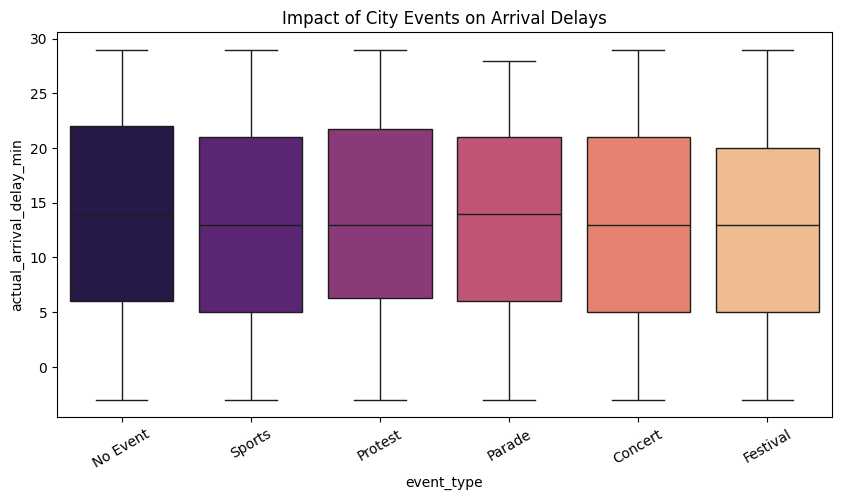

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="event_type", y="actual_arrival_delay_min", palette="magma")
plt.title("Impact of City Events on Arrival Delays")
plt.xticks(rotation=30)

Text(0, 0.5, 'Arrival Delay (min)')

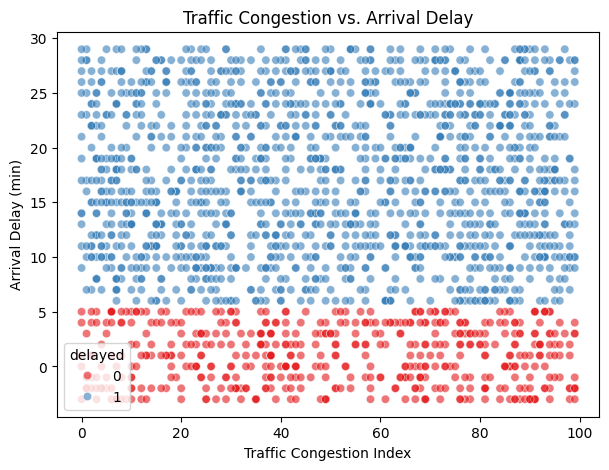

In [21]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="traffic_congestion_index", y="actual_arrival_delay_min", hue="delayed", palette="Set1", alpha=0.6)
plt.title("Traffic Congestion vs. Arrival Delay")
plt.xlabel("Traffic Congestion Index")
plt.ylabel("Arrival Delay (min)")

Text(0.5, 1.0, 'Correlation Heatmap')

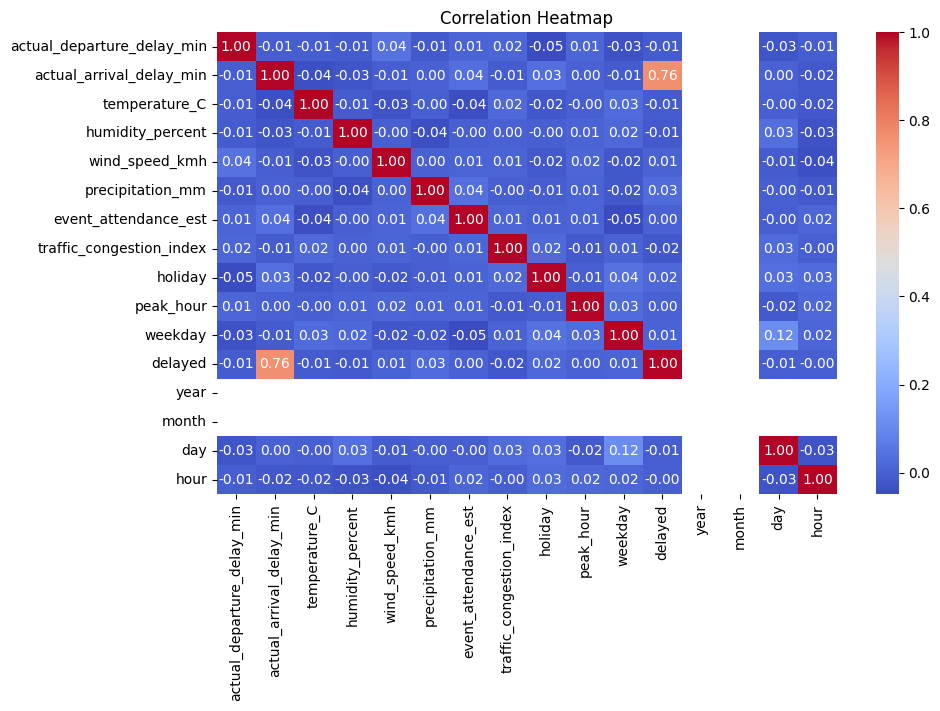

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")

<Axes: xlabel='delayed', ylabel='count'>

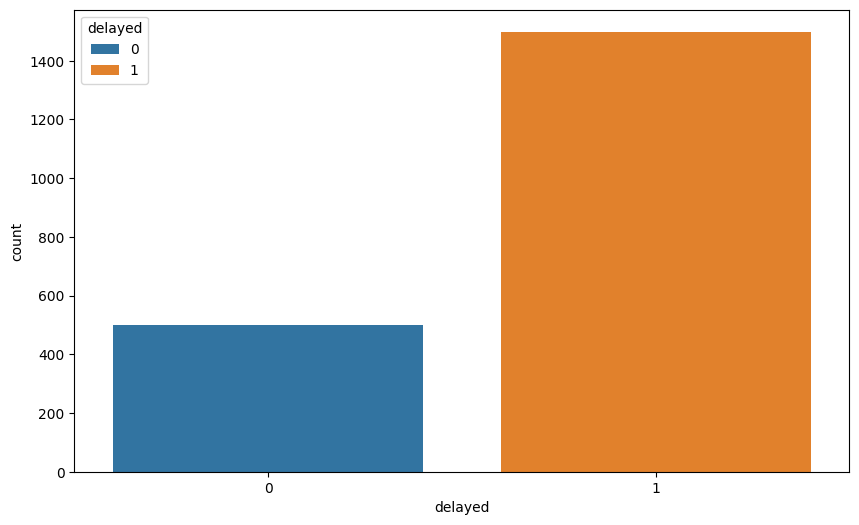

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='delayed',hue='delayed')

In [24]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed', 'year', 'month', 'day',
       'hour'],
      dtype='str')

In [25]:
cat_cols = df.select_dtypes(
    include=["object", "string"]
).columns

print("\nCategorical Columns:")
print(cat_cols)


Categorical Columns:
Index(['trip_id', 'transport_type', 'route_id', 'origin_station',
       'destination_station', 'weather_condition', 'event_type', 'season'],
      dtype='str')


In [26]:
df[cat_cols].head(15)

,trip_id,transport_type,route_id,origin_station,destination_station,weather_condition,event_type,season
0,T00000,Tram,Route_15,Station_31,Station_6,Storm,No Event,Winter
1,T00001,Metro,Route_12,Station_49,Station_32,Rain,No Event,Autumn
2,T00002,Bus,Route_16,Station_29,Station_42,Clear,Sports,Autumn
3,T00003,Tram,Route_19,Station_26,Station_18,Clear,No Event,Winter
4,T00004,Tram,Route_8,Station_18,Station_15,Snow,No Event,Spring
5,T00005,Metro,Route_17,Station_32,Station_40,Rain,Protest,Spring
6,T00006,Bus,Route_5,Station_22,Station_32,Storm,Parade,Spring
7,T00007,Bus,Route_16,Station_38,Station_9,Clear,No Event,Spring
8,T00008,Tram,Route_6,Station_17,Station_37,Clear,Concert,Summer
9,T00009,Train,Route_8,Station_23,Station_10,Fog,No Event,Summer


In [27]:
df = df.drop(columns=['trip_id'])

In [28]:
low_cardinality = [
    'transport_type',
    'weather_condition',
    'event_type',
    'season'
]

high_cardinality = [
    'route_id',
    'origin_station',
    'destination_station'
]

df = pd.get_dummies(
    df,
    columns=low_cardinality,
    drop_first=True
)

le = LabelEncoder()

for col in high_cardinality:
    df[col] = le.fit_transform(df[col])

In [29]:
df.columns

Index(['date', 'time', 'route_id', 'origin_station', 'destination_station',
       'scheduled_departure', 'scheduled_arrival',
       'actual_departure_delay_min', 'actual_arrival_delay_min',
       'temperature_C', 'humidity_percent', 'wind_speed_kmh',
       'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
       'holiday', 'peak_hour', 'weekday', 'delayed', 'year', 'month', 'day',
       'hour', 'transport_type_Metro', 'transport_type_Train',
       'transport_type_Tram', 'weather_condition_Cloudy',
       'weather_condition_Fog', 'weather_condition_Rain',
       'weather_condition_Snow', 'weather_condition_Storm',
       'event_type_Festival', 'event_type_No Event', 'event_type_Parade',
       'event_type_Protest', 'event_type_Sports', 'season_Spring',
       'season_Summer', 'season_Winter'],
      dtype='str')

In [30]:
X = df.drop(columns=['date','delayed'])
y = df['delayed']
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=40,test_size=0.2)

In [31]:
for col in ['time', 'scheduled_departure', 'scheduled_arrival']:
    X_train[f'{col}_hour'] = X_train[col].dt.hour
    X_train[f'{col}_minute'] = X_train[col].dt.minute

    X_test[f'{col}_hour'] = X_test[col].dt.hour
    X_test[f'{col}_minute'] = X_test[col].dt.minute

X_train.drop(columns=['time', 'scheduled_departure', 'scheduled_arrival'], inplace=True)
X_test.drop(columns=['time', 'scheduled_departure', 'scheduled_arrival'], inplace=True)

In [32]:
rf = RandomForestClassifier(n_estimators=100,random_state=10)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
pred

array([0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [33]:
print("Accuracy :", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("Precision :", precision_score(y_test, pred, average='weighted'))
print("Recall :", recall_score(y_test, pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

Accuracy : 1.0
Confusion Matrix:
 [[ 99   0]
 [  0 301]]
Precision : 1.0
Recall : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00       301

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [34]:
X_cv = X.copy()

for col in ['time', 'scheduled_departure', 'scheduled_arrival']:
    X_cv[f'{col}_hour'] = X_cv[col].dt.hour
    X_cv[f'{col}_minute'] = X_cv[col].dt.minute

X_cv.drop(columns=['time', 'scheduled_departure', 'scheduled_arrival'], inplace=True)


cv_scores = cross_val_score(rf, X_cv, y, cv=5, scoring="accuracy")

print(cv_scores)
print("Mean Accuracy:", cv_scores.mean())

[1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


In [35]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(15))

                       Feature  Importance
4     actual_arrival_delay_min    0.731326
5                temperature_C    0.017845
8             precipitation_mm    0.016976
39    scheduled_arrival_minute    0.016629
7               wind_speed_kmh    0.015953
1               origin_station    0.015898
10    traffic_congestion_index    0.015841
2          destination_station    0.015366
6             humidity_percent    0.014410
16                         day    0.013318
3   actual_departure_delay_min    0.011833
0                     route_id    0.011832
37  scheduled_departure_minute    0.011313
38      scheduled_arrival_hour    0.009511
34                   time_hour    0.009427


In [36]:
X_train.shape

(1600, 40)

In [38]:
import pandas as pd

# Create a single unseen row
unseen_row = pd.DataFrame([{
    "trip_id": "U00001",
    "date": pd.to_datetime("2023-02-05"),
    "time": pd.to_datetime("08:15:00"),
    "transport_type": "Bus",
    "route_id": "Route_7",
    "origin_station": "Station_12",
    "destination_station": "Station_25",
    "scheduled_departure": pd.to_datetime("08:15:00"),
    "scheduled_arrival": pd.to_datetime("09:00:00"),
    "actual_departure_delay_min": 0,   # leave as placeholder
    "actual_arrival_delay_min": 0,     # leave as placeholder
    "weather_condition": "Rain",
    "temperature_C": 18.5,
    "humidity_percent": 78,
    "wind_speed_kmh": 22,
    "precipitation_mm": 5.2,
    "event_type": "Concert",
    "event_attendance_est": 5000,
    "traffic_congestion_index": 65,
    "holiday": 0,
    "peak_hour": 1,
    "weekday": 6,   # Saturday
    "season": "Winter",
    "delayed": None,   # target to be predicted
    "year": 2023,
    "month": 2,
    "day": 5,
    "hour": 8
}])

print(unseen_row)


  trip_id       date                time transport_type route_id  \
0  U00001 2023-02-05 2026-07-31 08:15:00            Bus  Route_7   

  origin_station destination_station scheduled_departure   scheduled_arrival  \
0     Station_12          Station_25 2026-07-31 08:15:00 2026-07-31 09:00:00   

   actual_departure_delay_min  ...  traffic_congestion_index holiday  \
0                           0  ...                        65       0   

   peak_hour  weekday  season  delayed  year  month  day  hour  
0          1        6  Winter     None  2023      2    5     8  

[1 rows x 28 columns]


In [41]:
X_test


,route_id,origin_station,destination_station,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,...,event_type_Sports,season_Spring,season_Summer,season_Winter,time_hour,time_minute,scheduled_departure_hour,scheduled_departure_minute,scheduled_arrival_hour,scheduled_arrival_minute
423,8,21,12,2,-2,3.3,73,19,18.6,500,...,False,False,False,True,14,45,14,45,15,14
1495,5,6,5,15,9,-3.2,96,38,17.9,500,...,False,False,True,False,18,45,18,47,19,20
1618,17,21,18,0,24,27.3,59,5,4.1,50000,...,True,False,True,False,1,30,1,31,2,2
1099,2,33,38,2,20,-4.3,52,46,5.4,0,...,False,False,False,False,15,45,15,48,16,27
1307,16,12,35,10,15,34.3,80,24,13.7,0,...,False,False,True,False,19,45,19,46,20,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,11,42,31,13,25,-4.7,74,26,0.0,2000,...,True,False,False,False,21,45,21,45,22,8
1379,11,18,24,10,28,25.7,63,43,13.5,0,...,False,True,False,False,13,45,13,47,14,20
837,0,40,45,13,23,-2.5,65,24,7.8,0,...,False,True,False,False,22,15,22,16,22,37
877,11,47,15,14,16,22.4,43,52,10.4,0,...,False,False,True,False,8,15,8,18,9,12


In [42]:
import pandas as pd

# Single unseen row for prediction
unseen_row = pd.DataFrame([{
    "route_id": 9,
    "origin_station": 12,
    "destination_station": 25,
    "actual_departure_delay_min": 3,
    "actual_arrival_delay_min": 7,
    "temperature_C": 18.5,
    "humidity_percent": 78,
    "wind_speed_kmh": 22,
    "precipitation_mm": 5.2,
    "event_attendance_est": 5000,
    "traffic_congestion_index": 65,
    "holiday": 0,
    "peak_hour": 1,
    "weekday": 6,   # Saturday
    "year": 2023,
    "month": 2,
    "day": 5,
    "hour": 8,
    
    # One-hot encoded transport_type
    "transport_type_Metro": 0,
    "transport_type_Train": 0,
    "transport_type_Tram": 0,
    
    # One-hot encoded weather_condition
    "weather_condition_Cloudy": 0,
    "weather_condition_Fog": 0,
    "weather_condition_Rain": 1,
    "weather_condition_Snow": 0,
    "weather_condition_Storm": 0,
    
    # One-hot encoded event_type
    "event_type_Festival": 0,
    "event_type_No Event": 0,
    "event_type_Parade": 0,
    "event_type_Protest": 0,
    "event_type_Sports": 0,
    
    # One-hot encoded season
    "season_Spring": 0,
    "season_Summer": 0,
    "season_Winter": 1,
    
    # Time features
    "time_hour": 8,
    "time_minute": 15,
    "scheduled_departure_hour": 8,
    "scheduled_departure_minute": 15,
    "scheduled_arrival_hour": 9,
    "scheduled_arrival_minute": 0
}])

print(unseen_row)


   route_id  origin_station  destination_station  actual_departure_delay_min  \
0         9              12                   25                           3   

   actual_arrival_delay_min  temperature_C  humidity_percent  wind_speed_kmh  \
0                         7           18.5                78              22   

   precipitation_mm  event_attendance_est  ...  event_type_Sports  \
0               5.2                  5000  ...                  0   

   season_Spring  season_Summer  season_Winter  time_hour  time_minute  \
0              0              0              1          8           15   

   scheduled_departure_hour  scheduled_departure_minute  \
0                         8                          15   

   scheduled_arrival_hour  scheduled_arrival_minute  
0                       9                         0  

[1 rows x 40 columns]


In [43]:
unseen_pred = rf.predict(unseen_row)

if unseen_pred = 0:
    return('')

array([1])